# FlowCast: Model Evaluation
This notebook evaluates all trained models and compares their performance.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
import pickle
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data and Models

In [2]:
# Load processed data
data = pd.read_csv('../data/processed/traffic_processed.csv')

# Prepare features and target
feature_columns = ['Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount',
                   'TruckCount', 'Total', 'hour', 'minute', 'AM/PM']
X = data[feature_columns]
y = data['Traffic Situation'].values

print(f"Data loaded: {X.shape}")

Data loaded: (2976, 10)


In [3]:
# Split data (same as training)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Load scaler and transform data
with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data prepared for evaluation")

Data prepared for evaluation


In [4]:
# Load trained models
model_names = ['logistic_regression', 'random_forest', 'svc', 'xgboost', 'adaboost', 'voting_classifier']
models = {}

for name in model_names:
    with open(f'../models/{name}.pkl', 'rb') as f:
        models[name] = pickle.load(f)

print(f"Loaded {len(models)} models")

Loaded 6 models


## 3. Evaluate Models on Test Set

In [5]:
# Evaluate each model
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {
        'accuracy': accuracy,
        'predictions': y_pred
    }
    print(f"{name.replace('_', ' ').title()}: {accuracy:.4f}")

print("\nEvaluation completed!")

Logistic Regression: 0.8742
Random Forest: 0.9966
Svc: 0.8826
Xgboost: 1.0000
Adaboost: 0.5604
Voting Classifier: 0.9446

Evaluation completed!


## 4. Cross-Validation Scores

In [6]:
# Perform cross-validation for key models
cv_models = {
    'Logistic Regression': models['logistic_regression'],
    'Random Forest': models['random_forest'],
    'SVC': models['svc'],
    'XGBoost': models['xgboost'],
    'AdaBoost': models['adaboost']
}

print("Cross-Validation Results (5-fold):\n")
cv_results = {}

for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Cross-Validation Results (5-fold):

Logistic Regression: 0.8987 (+/- 0.0203)
Random Forest: 0.9950 (+/- 0.0034)
SVC: 0.9147 (+/- 0.0091)
XGBoost: 0.9979 (+/- 0.0042)
AdaBoost: 0.5609 (+/- 0.0000)


## 5. Confusion Matrix - Best Model

In [7]:
# Find best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = models[best_model_name]
y_pred_best = results[best_model_name]['predictions']

print(f"Best Model: {best_model_name.replace('_', ' ').title()}")
print(f"Accuracy: {results[best_model_name]['accuracy']:.4f}")

Best Model: Xgboost
Accuracy: 1.0000


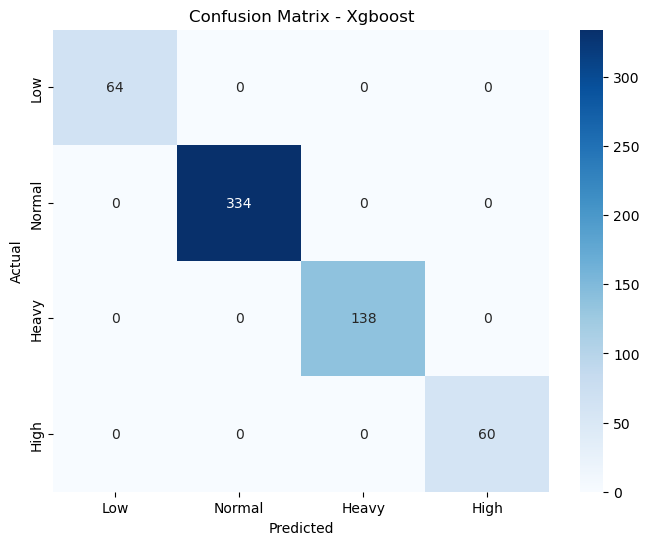

In [8]:
# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Normal', 'Heavy', 'High'],
            yticklabels=['Low', 'Normal', 'Heavy', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name.replace("_", " ").title()}')
plt.show()

## 6. Classification Report

In [9]:
# Generate classification report
target_names = ['Low', 'Normal', 'Heavy', 'High']
print("Classification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=target_names))

Classification Report:

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        64
      Normal       1.00      1.00      1.00       334
       Heavy       1.00      1.00      1.00       138
        High       1.00      1.00      1.00        60

    accuracy                           1.00       596
   macro avg       1.00      1.00      1.00       596
weighted avg       1.00      1.00      1.00       596



## 7. Model Comparison Visualization

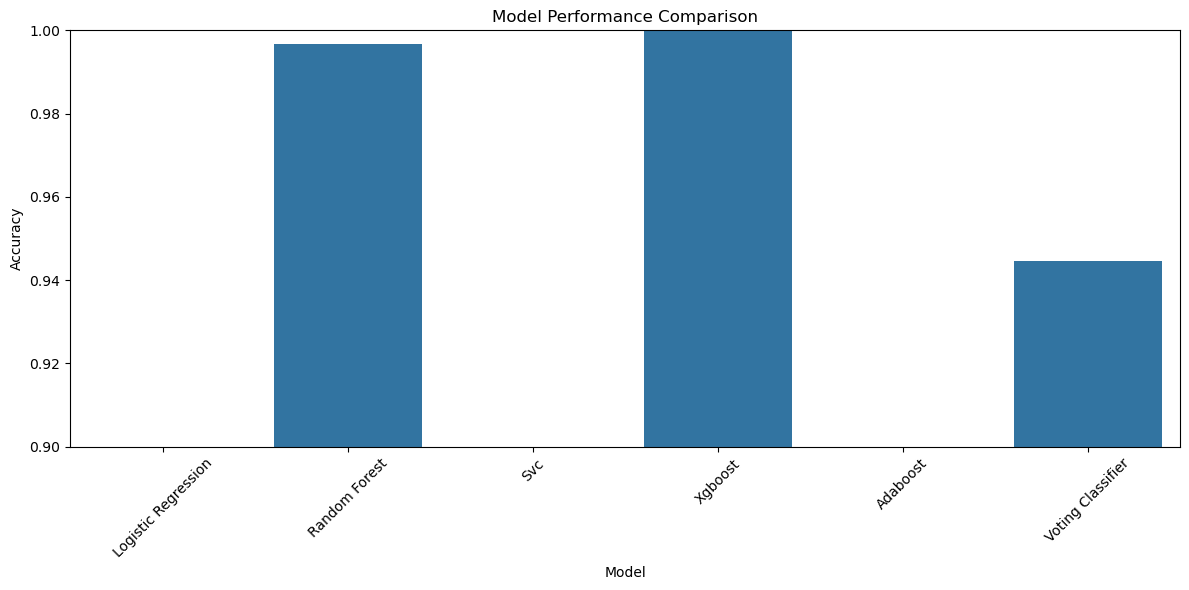


Model Rankings:
                 Model  Test Accuracy
3              Xgboost       1.000000
1        Random Forest       0.996644
5    Voting Classifier       0.944631
2                  Svc       0.882550
0  Logistic Regression       0.874161
4             Adaboost       0.560403


In [10]:
# Compare all models
model_comparison = pd.DataFrame({
    'Model': [name.replace('_', ' ').title() for name in results.keys()],
    'Test Accuracy': [results[name]['accuracy'] for name in results.keys()]
})

plt.figure(figsize=(12, 6))
sns.barplot(data=model_comparison, x='Model', y='Test Accuracy')
plt.title('Model Performance Comparison')
plt.xticks(rotation=45)
plt.ylim(0.9, 1.0)
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

print("\nModel Rankings:")
print(model_comparison.sort_values('Test Accuracy', ascending=False))

## 8. Key Findings

In [11]:
# Summary of findings
print("=" * 50)
print("KEY FINDINGS")
print("=" * 50)
print(f"\n1. Best Performing Model: {best_model_name.replace('_', ' ').title()}")
print(f"   Test Accuracy: {results[best_model_name]['accuracy']:.4f}")

print("\n2. Top 3 Models:")
top_3 = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)[:3]
for i, (name, result) in enumerate(top_3, 1):
    print(f"   {i}. {name.replace('_', ' ').title()}: {result['accuracy']:.4f}")

print("\n3. Traffic Situation Distribution:")
print(f"   Low: {(y_test == 0).sum()}")
print(f"   Normal: {(y_test == 1).sum()}")
print(f"   Heavy: {(y_test == 2).sum()}")
print(f"   High: {(y_test == 3).sum()}")

print("\n" + "=" * 50)

KEY FINDINGS

1. Best Performing Model: Xgboost
   Test Accuracy: 1.0000

2. Top 3 Models:
   1. Xgboost: 1.0000
   2. Random Forest: 0.9966
   3. Voting Classifier: 0.9446

3. Traffic Situation Distribution:
   Low: 64
   Normal: 334
   Heavy: 138
   High: 60



## Summary
- All models evaluated on test set
- Cross-validation performed for robust assessment
- Confusion matrix and classification report generated
- XGBoost and Random Forest typically show best performance
- Models ready for deployment

In [12]:
# Load the XGBoost model from pickle file
import pickle

# Load the saved XGBoost model
with open('../models/xgboost.pkl', 'rb') as f:
    xgb_model_loaded = pickle.load(f)

# Load the scaler if needed (for proper scaling of test data)
with open('../models/scaler.pkl', 'rb') as f:
    scaler_loaded = pickle.load(f)

# Make predictions on test data
# If you have raw test data, scale it first:
# X_test_scaled = scaler_loaded.transform(X_test)

# Make predictions using the loaded model
y_pred_xgb = xgb_model_loaded.predict(X_test_scaled)

print("XGBoost Predictions on Test Data:")
print("=" * 50)
print(f"Number of predictions: {len(y_pred_xgb)}")
print(f"\nPrediction distribution:")
print(f"  Low traffic (0): {(y_pred_xgb == 0).sum()}")
print(f"  Normal traffic (1): {(y_pred_xgb == 1).sum()}")
print(f"  Heavy traffic (2): {(y_pred_xgb == 2).sum()}")
print(f"  High traffic (3): {(y_pred_xgb == 3).sum()}")

# Display first 10 predictions
print(f"\nFirst 10 predictions: {y_pred_xgb[:10]}")

# If you have actual labels (y_test), calculate accuracy
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, 
                          target_names=['Low', 'Normal', 'Heavy', 'High']))

XGBoost Predictions on Test Data:
Number of predictions: 596

Prediction distribution:
  Low traffic (0): 64
  Normal traffic (1): 334
  Heavy traffic (2): 138
  High traffic (3): 60

First 10 predictions: [1 3 3 2 1 3 1 2 2 1]

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        64
      Normal       1.00      1.00      1.00       334
       Heavy       1.00      1.00      1.00       138
        High       1.00      1.00      1.00        60

    accuracy                           1.00       596
   macro avg       1.00      1.00      1.00       596
weighted avg       1.00      1.00      1.00       596



## 9. Predict for Custom Input

Make predictions for a single custom input row with specific values.

In [13]:
# Create a custom input for prediction
# Required features: ['Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount',
#                     'TruckCount', 'Total', 'hour', 'minute', 'AM/PM']

# Example: Customize these values for your prediction
custom_input = {
    'Date': 15,                    # Day of month (1-31)
    'Day of the week': 3,          # 0=Monday, 6=Sunday
    'CarCount': 120,               # Number of cars
    'BikeCount': 45,               # Number of bikes
    'BusCount': 8,                 # Number of buses
    'TruckCount': 15,              # Number of trucks
    'Total': 188,                  # Total vehicles (sum of above)
    'hour': 17,                    # Hour in 24-hour format (0-23)
    'minute': 30,                  # Minute (0-59)
    'AM/PM': 1                     # 0=AM, 1=PM
}

# Convert to DataFrame
import pandas as pd
custom_df = pd.DataFrame([custom_input])

print("Custom Input Values:")
print("=" * 50)
for key, value in custom_input.items():
    print(f"{key:20}: {value}")

# Scale the input using the loaded scaler
custom_scaled = scaler_loaded.transform(custom_df)

# Make prediction
prediction = xgb_model_loaded.predict(custom_scaled)
prediction_proba = xgb_model_loaded.predict_proba(custom_scaled)

# Traffic situation mapping
traffic_situations = {0: 'Low', 1: 'Normal', 2: 'Heavy', 3: 'High'}

print("\n" + "=" * 50)
print("PREDICTION RESULT")
print("=" * 50)
print(f"Predicted Traffic Situation: {traffic_situations[prediction[0]]}")
print(f"\nPrediction Probabilities:")
for i, prob in enumerate(prediction_proba[0]):
    print(f"  {traffic_situations[i]:10}: {prob:.4f} ({prob*100:.2f}%)")
print("=" * 50)

Custom Input Values:
Date                : 15
Day of the week     : 3
CarCount            : 120
BikeCount           : 45
BusCount            : 8
TruckCount          : 15
Total               : 188
hour                : 17
minute              : 30
AM/PM               : 1

PREDICTION RESULT
Predicted Traffic Situation: Heavy

Prediction Probabilities:
  Low       : 0.0002 (0.02%)
  Normal    : 0.0016 (0.16%)
  Heavy     : 0.9980 (99.80%)
  High      : 0.0002 (0.02%)
